In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

pd.set_option('display.float_format', lambda x: '{:.2f}'.format(x))
np.set_printoptions(suppress=True)

df_customers = pd.read_csv(r"C:\code\project2_classification\Project2_DataCollection_Resources\customers.csv")
df_loans = pd.read_csv(r"C:\code\project2_classification\Project2_DataCollection_Resources\loans.csv")
df_bureau = pd.read_csv(r"C:\code\project2_classification\Project2_DataCollection_Resources\bureau_data.csv")

df_customers.shape, df_loans.shape, df_bureau.shape

((50000, 12), (50000, 15), (50000, 8))

In [2]:
df=pd.merge(df_customers,df_loans, on='cust_id')

In [3]:
df=pd.merge(df,df_bureau)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cust_id                      50000 non-null  object 
 1   age                          50000 non-null  int64  
 2   gender                       50000 non-null  object 
 3   marital_status               50000 non-null  object 
 4   employment_status            50000 non-null  object 
 5   income                       50000 non-null  int64  
 6   number_of_dependants         50000 non-null  int64  
 7   residence_type               49938 non-null  object 
 8   years_at_current_address     50000 non-null  int64  
 9   city                         50000 non-null  object 
 10  state                        50000 non-null  object 
 11  zipcode                      50000 non-null  int64  
 12  loan_id                      50000 non-null  object 
 13  loan_purpose    

In [5]:
df['default']=df['default'].astype(int)
df.default.value_counts()

default
0    45703
1     4297
Name: count, dtype: int64

In [6]:
X=df.drop('default',axis='columns')
y=df['default']

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.25)

In [8]:
df_train=pd.concat([X_train,y_train],axis='columns')
df_test=pd.concat([X_test,y_test],axis='columns')

In [9]:
df_train.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default
27628,C27629,41,M,Married,Self-Employed,11446000,3,Owned,14,Lucknow,...,2022-04-28,2022-05-14,1,2,37,12,68,4,25,0
37885,C37886,49,F,Married,Self-Employed,10582000,4,Owned,4,Ahmedabad,...,2023-05-07,2023-05-14,3,1,46,3,16,7,26,0
23412,C23413,31,M,Single,Salaried,1335000,1,Mortgage,31,Lucknow,...,2021-11-25,2021-12-25,4,2,150,22,134,6,54,0
3235,C03236,41,F,Married,Salaried,7190000,3,Mortgage,15,Chennai,...,2019-11-19,2019-12-13,4,1,107,3,24,7,63,0
49581,C49582,48,M,Married,Self-Employed,3608000,3,Mortgage,4,Ahmedabad,...,2024-07-07,2024-07-14,1,2,34,15,80,2,83,1


In [10]:
df_train.shape,df_test.shape

((37500, 33), (12500, 33))

In [11]:
df_train.isna().sum()

cust_id                         0
age                             0
gender                          0
marital_status                  0
employment_status               0
income                          0
number_of_dependants            0
residence_type                 42
years_at_current_address        0
city                            0
state                           0
zipcode                         0
loan_id                         0
loan_purpose                    0
loan_type                       0
sanction_amount                 0
loan_amount                     0
processing_fee                  0
gst                             0
net_disbursement                0
loan_tenure_months              0
principal_outstanding           0
bank_balance_at_application     0
disbursal_date                  0
installment_start_dt            0
number_of_open_accounts         0
number_of_closed_accounts       0
total_loan_months               0
delinquent_months               0
total_dpd     

In [12]:
df_train.residence_type.unique()

array(['Owned', 'Mortgage', 'Rented', nan], dtype=object)

In [13]:
mode_residence=df.residence_type.mode()[0]
mode_residence

'Owned'

In [14]:
df_train.residence_type.fillna(mode_residence,inplace=True)

C:\Users\ayush\AppData\Local\Temp\ipykernel_2760\1744904132.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train.residence_type.fillna(mode_residence,inplace=True)


In [15]:
df_test.residence_type.fillna(mode_residence,inplace=True)

C:\Users\ayush\AppData\Local\Temp\ipykernel_2760\838491418.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_test.residence_type.fillna(mode_residence,inplace=True)


In [16]:
df_train.duplicated().sum()

np.int64(0)

In [17]:
df_train.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default'],
      dtype='object')

In [18]:
columns_continious= df_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
columns_categorical = df_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()



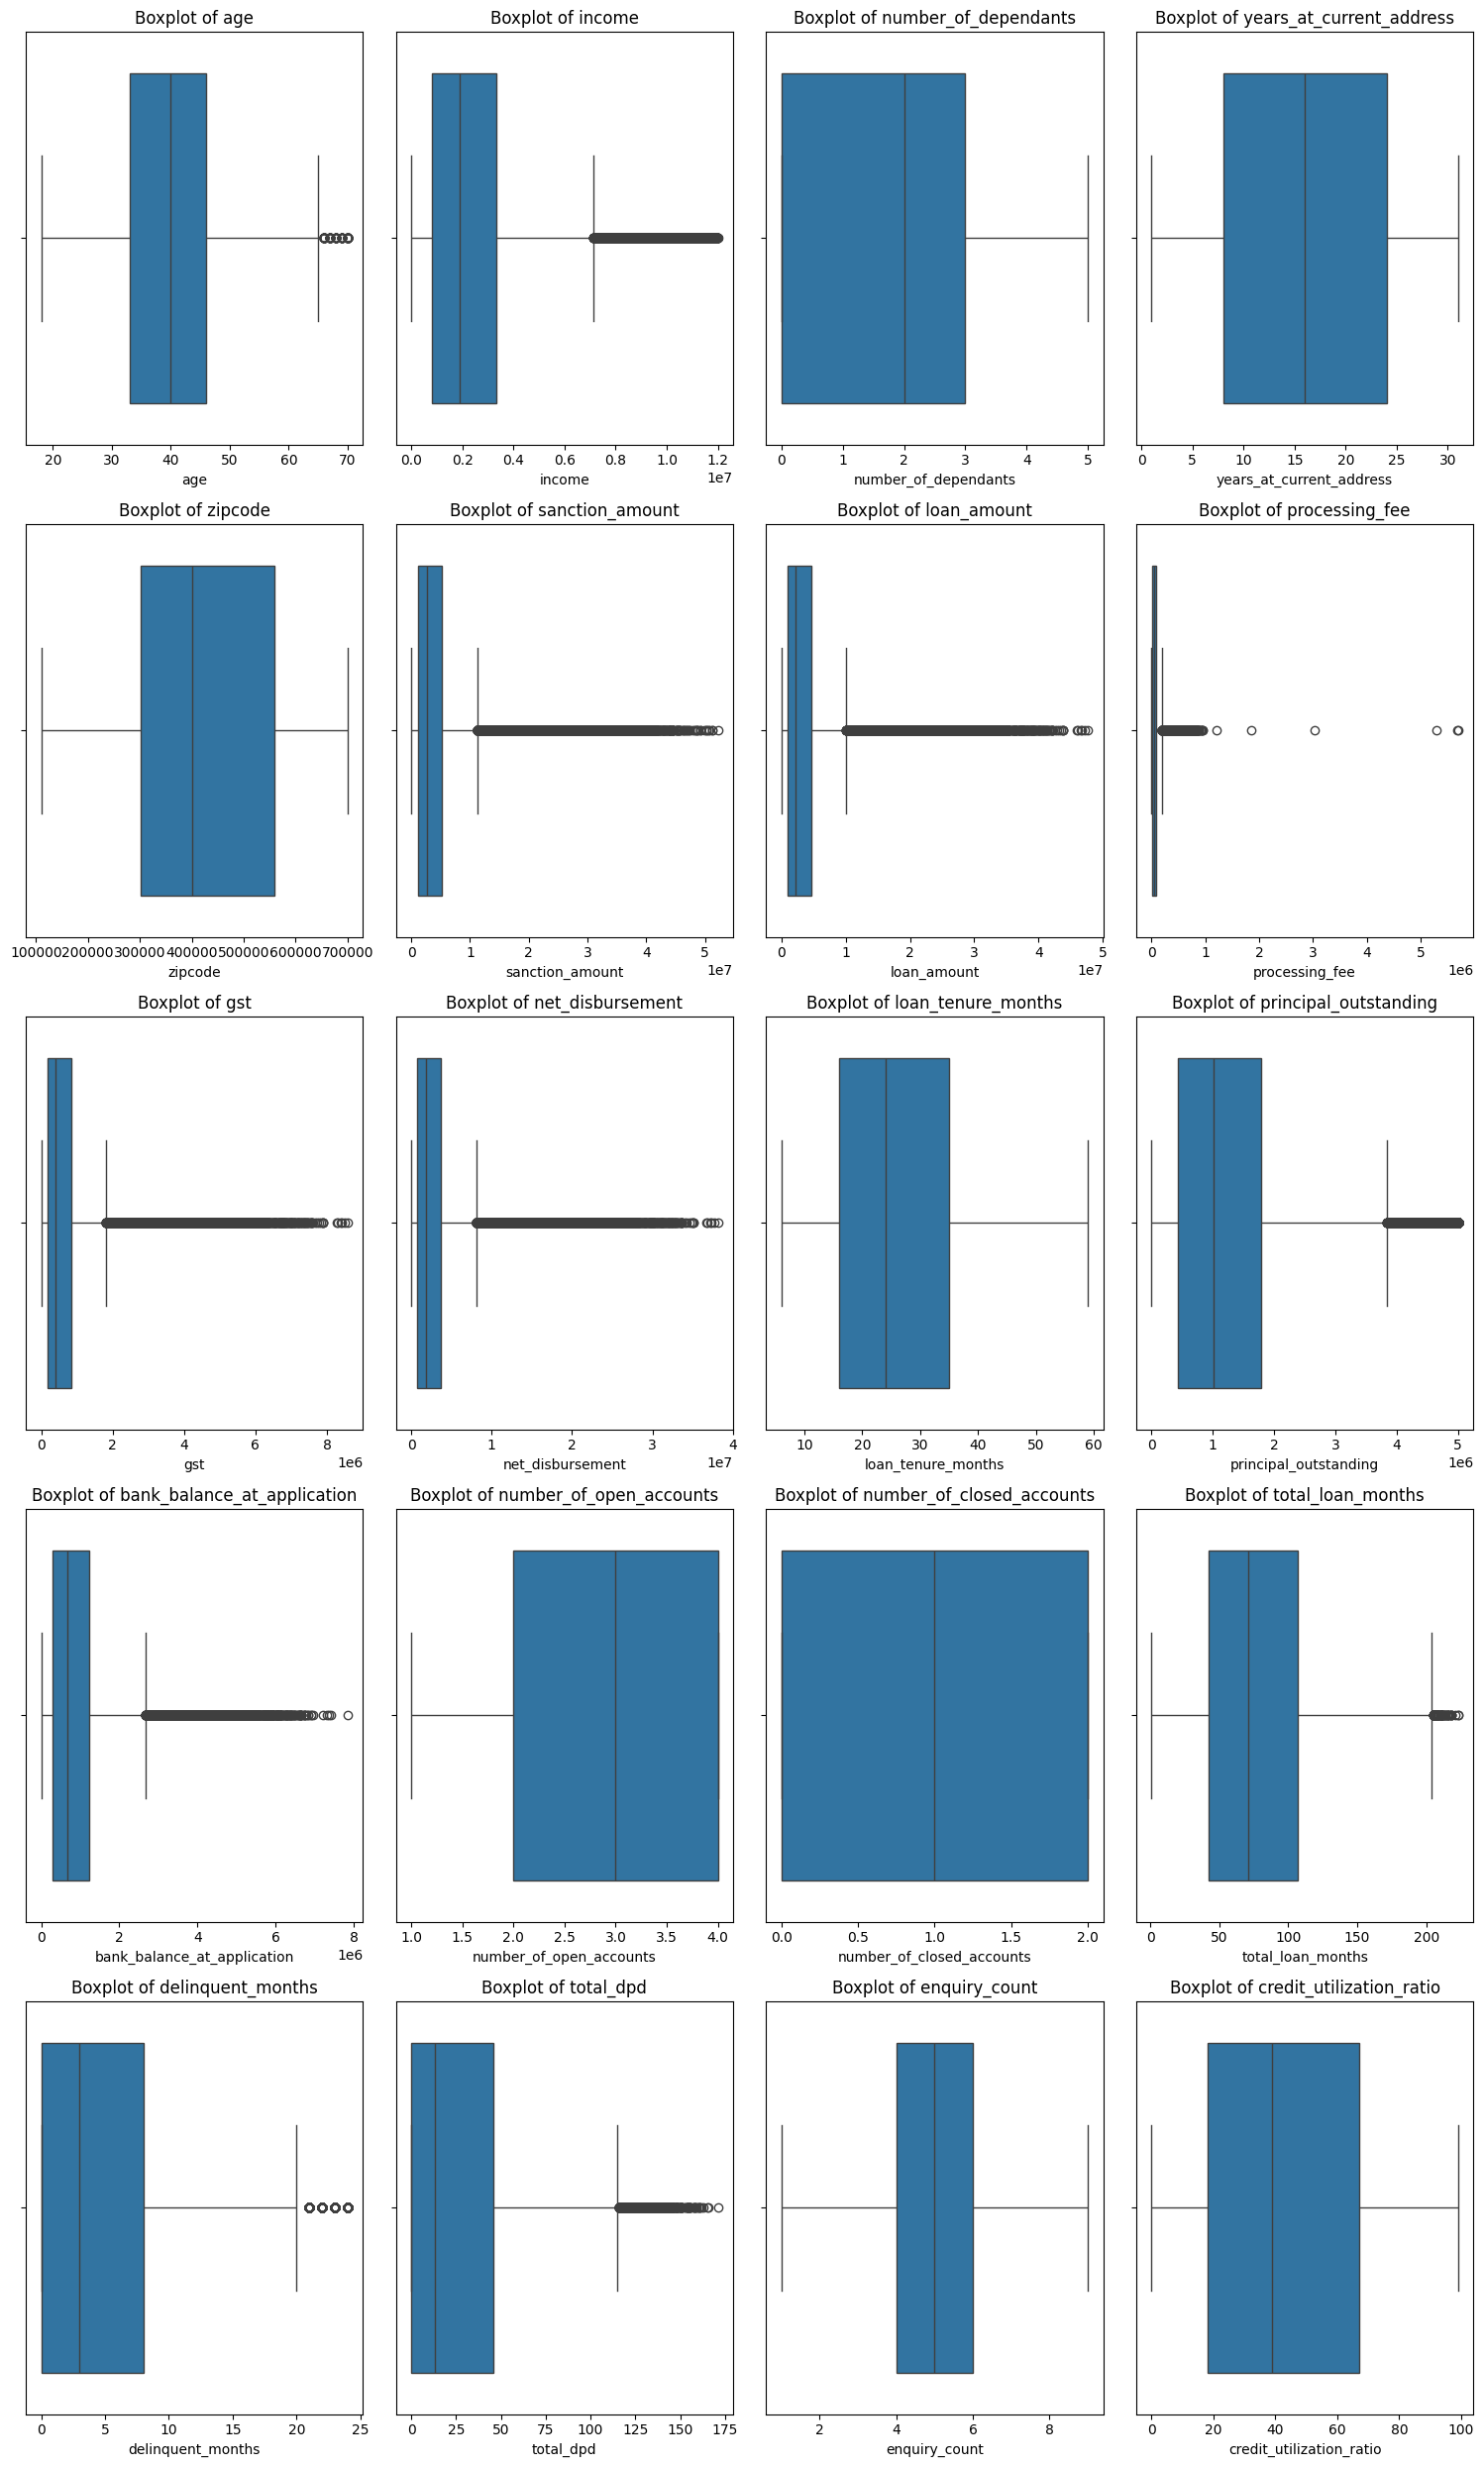

In [19]:
# Exclude the target variable 'default' from continuous/numerical features
columns_continious = [col for col in df_train.select_dtypes(include=['int64', 'float64']).columns if col != 'default']

num_plots = len(columns_continious)
num_cols = 4  # Number of plots per row
num_rows = (num_plots + num_cols - 1) // num_cols  # Calculate the number of rows needed

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
axes = axes.flatten()  # Flatten the axes array for easier indexing

for i, col in enumerate(columns_continious):
    sns.boxplot(x=df_train[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

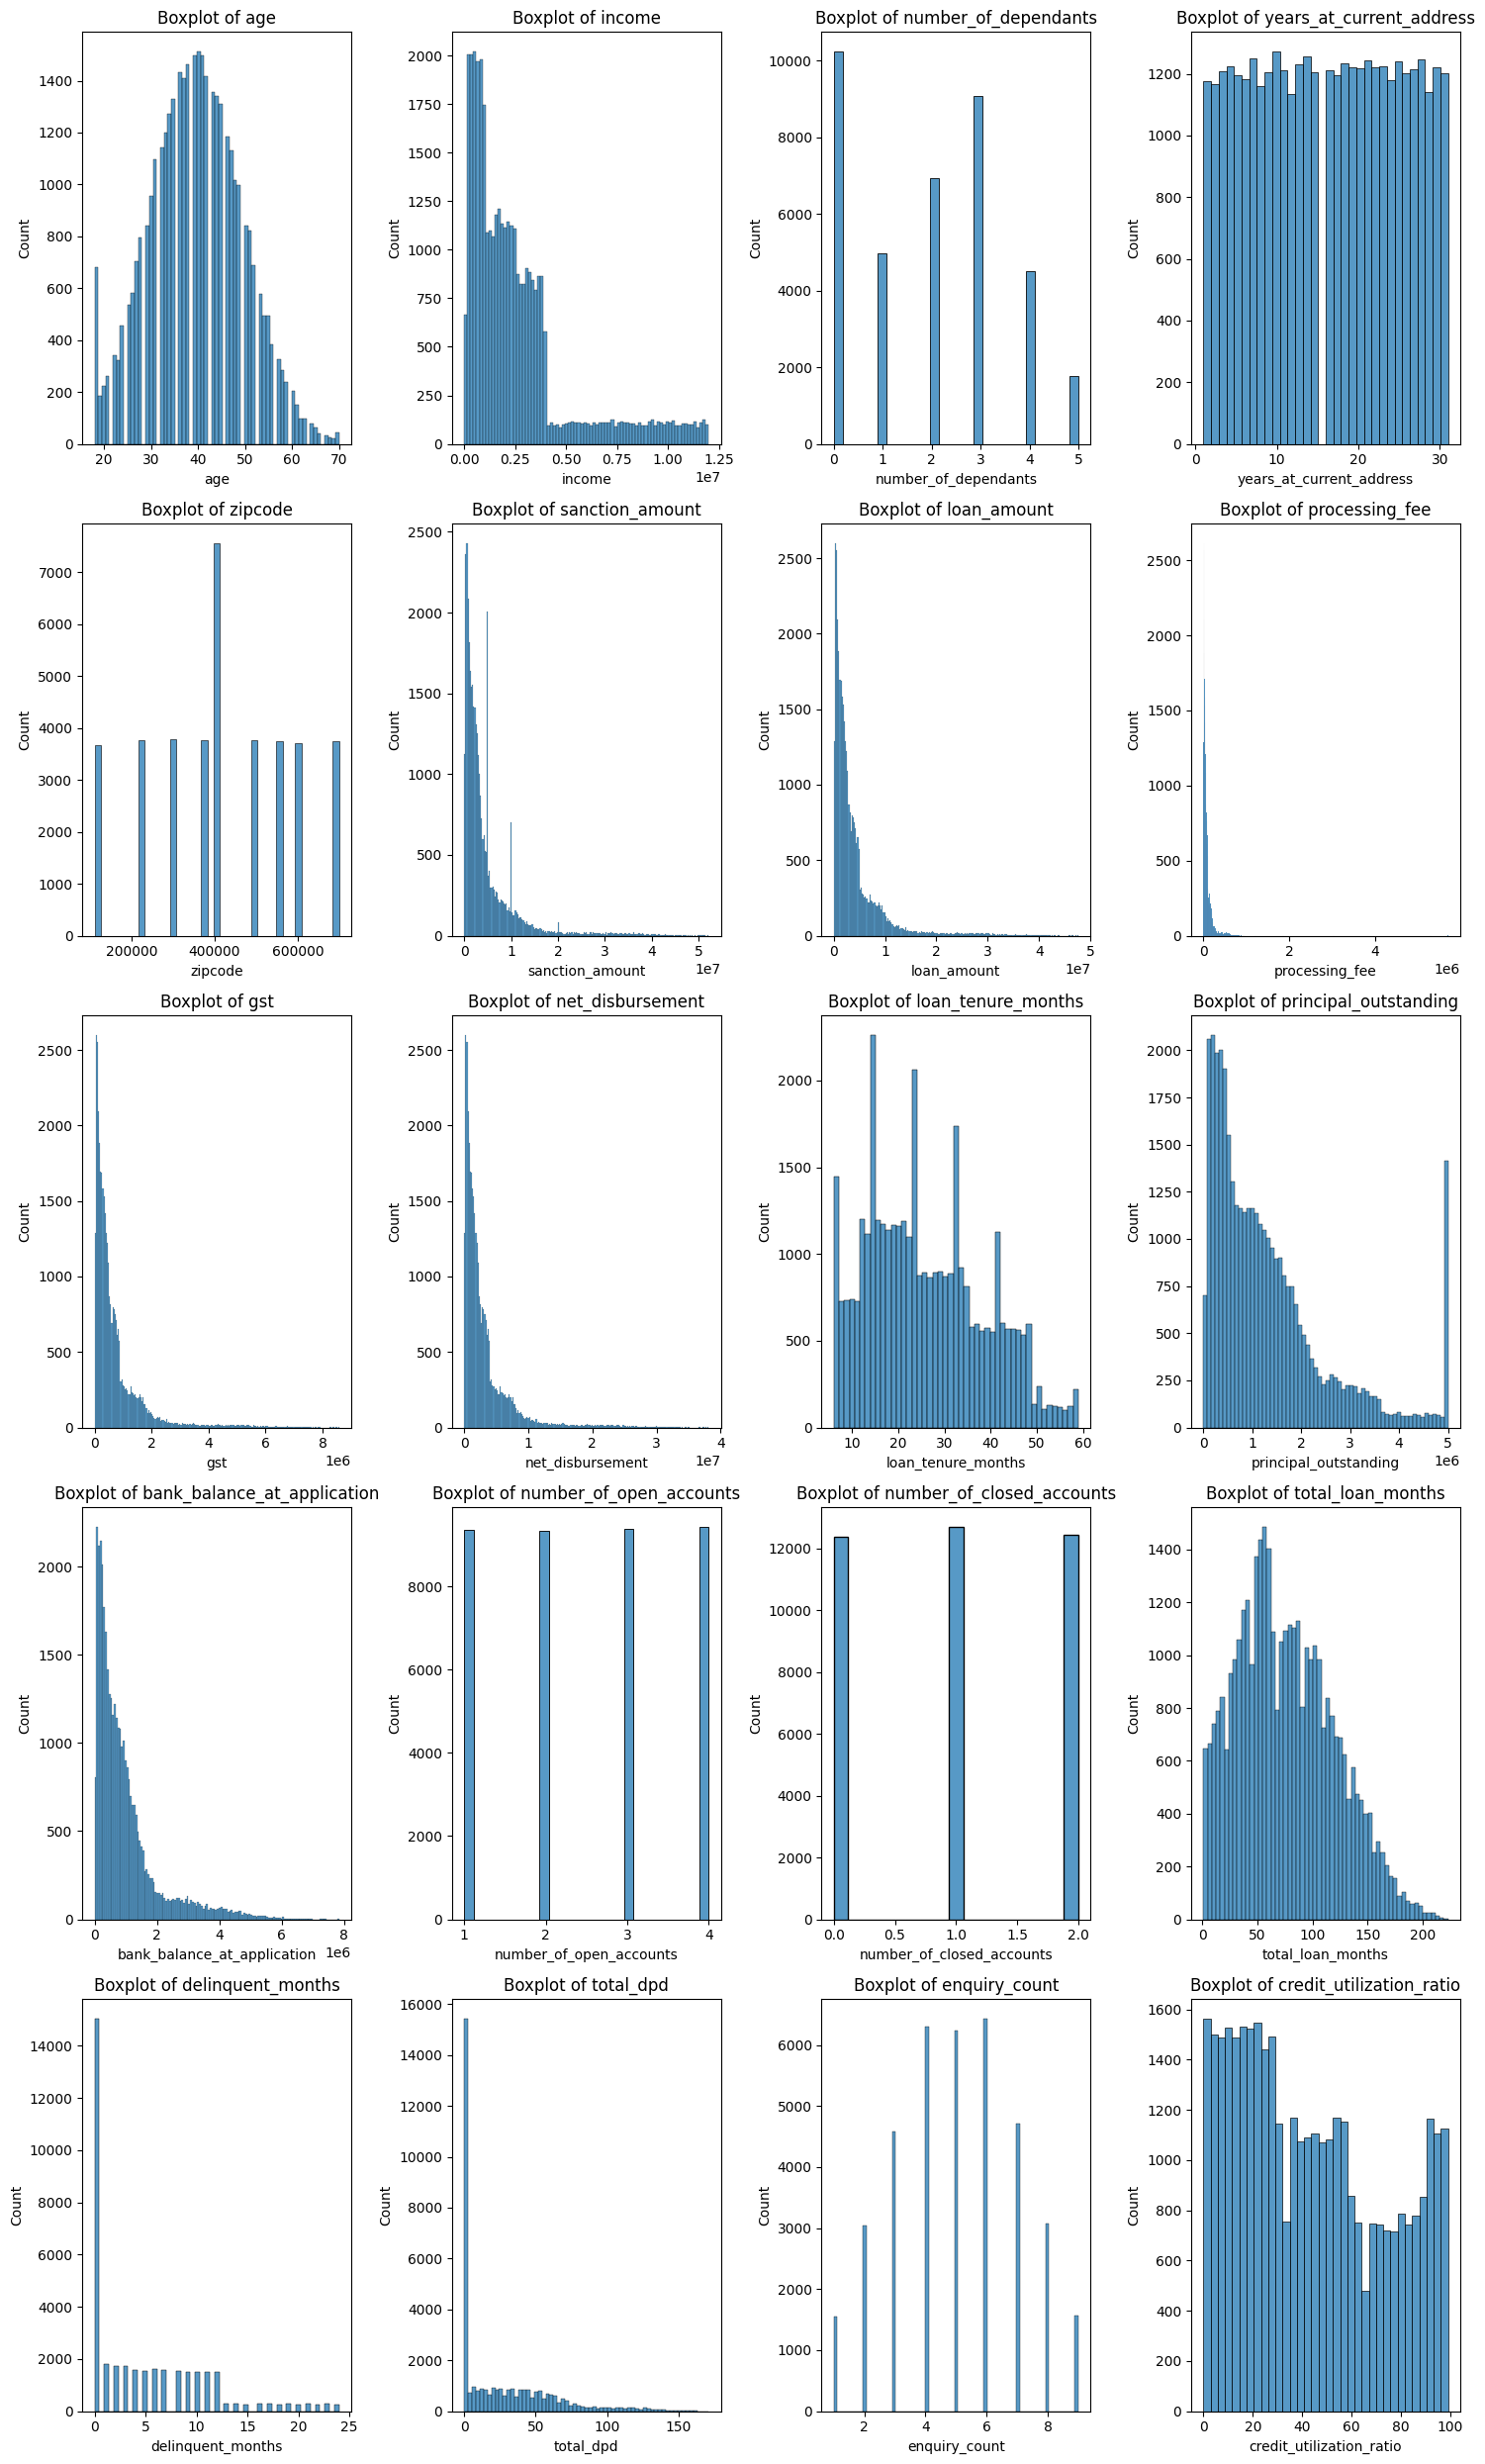

In [20]:
num_plots = len(columns_continious)
num_cols = 4  # Number of plots per row
num_rows = (num_plots + num_cols - 1) // num_cols  # Calculate the number of rows needed

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
axes = axes.flatten()  # Flatten the axes array for easier indexing

for i, col in enumerate(columns_continious):
    sns.histplot(x=df_train[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [21]:
df_train.processing_fee.describe()

count     37500.00
mean      80469.40
std      119220.25
min           0.00
25%       19280.00
50%       44880.00
75%       92485.00
max     5698029.90
Name: processing_fee, dtype: float64

In [22]:
df_train[(df_train.processing_fee/df_train.processing_fee.max())>0.03][["loan_amount", "processing_fee"]]

,loan_amount,processing_fee
27628,9785000,195700.00
49581,9449000,188980.00
14265,11155000,223100.00
31248,16103000,322060.00
25061,20640000,412800.00
...,...,...
42725,9421000,188420.00
19289,14260000,285200.00
7021,30198000,603960.00
4714,11416000,228320.00


In [23]:
df_train['loan_purpose'].unique()

array(['Auto', 'Personal', 'Home', 'Education', 'Personaal'], dtype=object)

In [26]:
df_train['loan_purpose']=df_train['loan_purpose'].replace('Personaal','Personal')


### EDA

In [27]:
columns_continious

['age',
 'income',
 'number_of_dependants',
 'years_at_current_address',
 'zipcode',
 'sanction_amount',
 'loan_amount',
 'processing_fee',
 'gst',
 'net_disbursement',
 'loan_tenure_months',
 'principal_outstanding',
 'bank_balance_at_application',
 'number_of_open_accounts',
 'number_of_closed_accounts',
 'total_loan_months',
 'delinquent_months',
 'total_dpd',
 'enquiry_count',
 'credit_utilization_ratio']

<Axes: xlabel='age', ylabel='Density'>

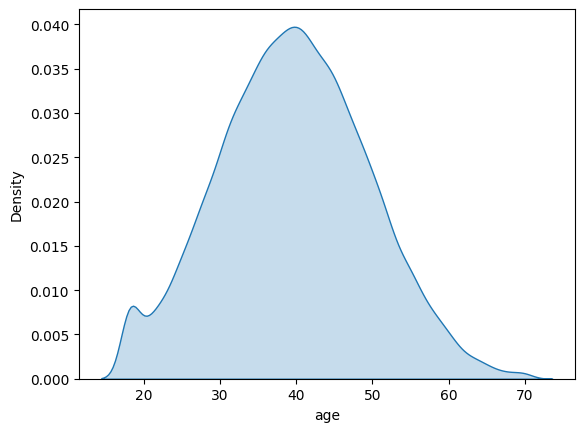

In [29]:
sns.kdeplot(df_train.age,fill=True)

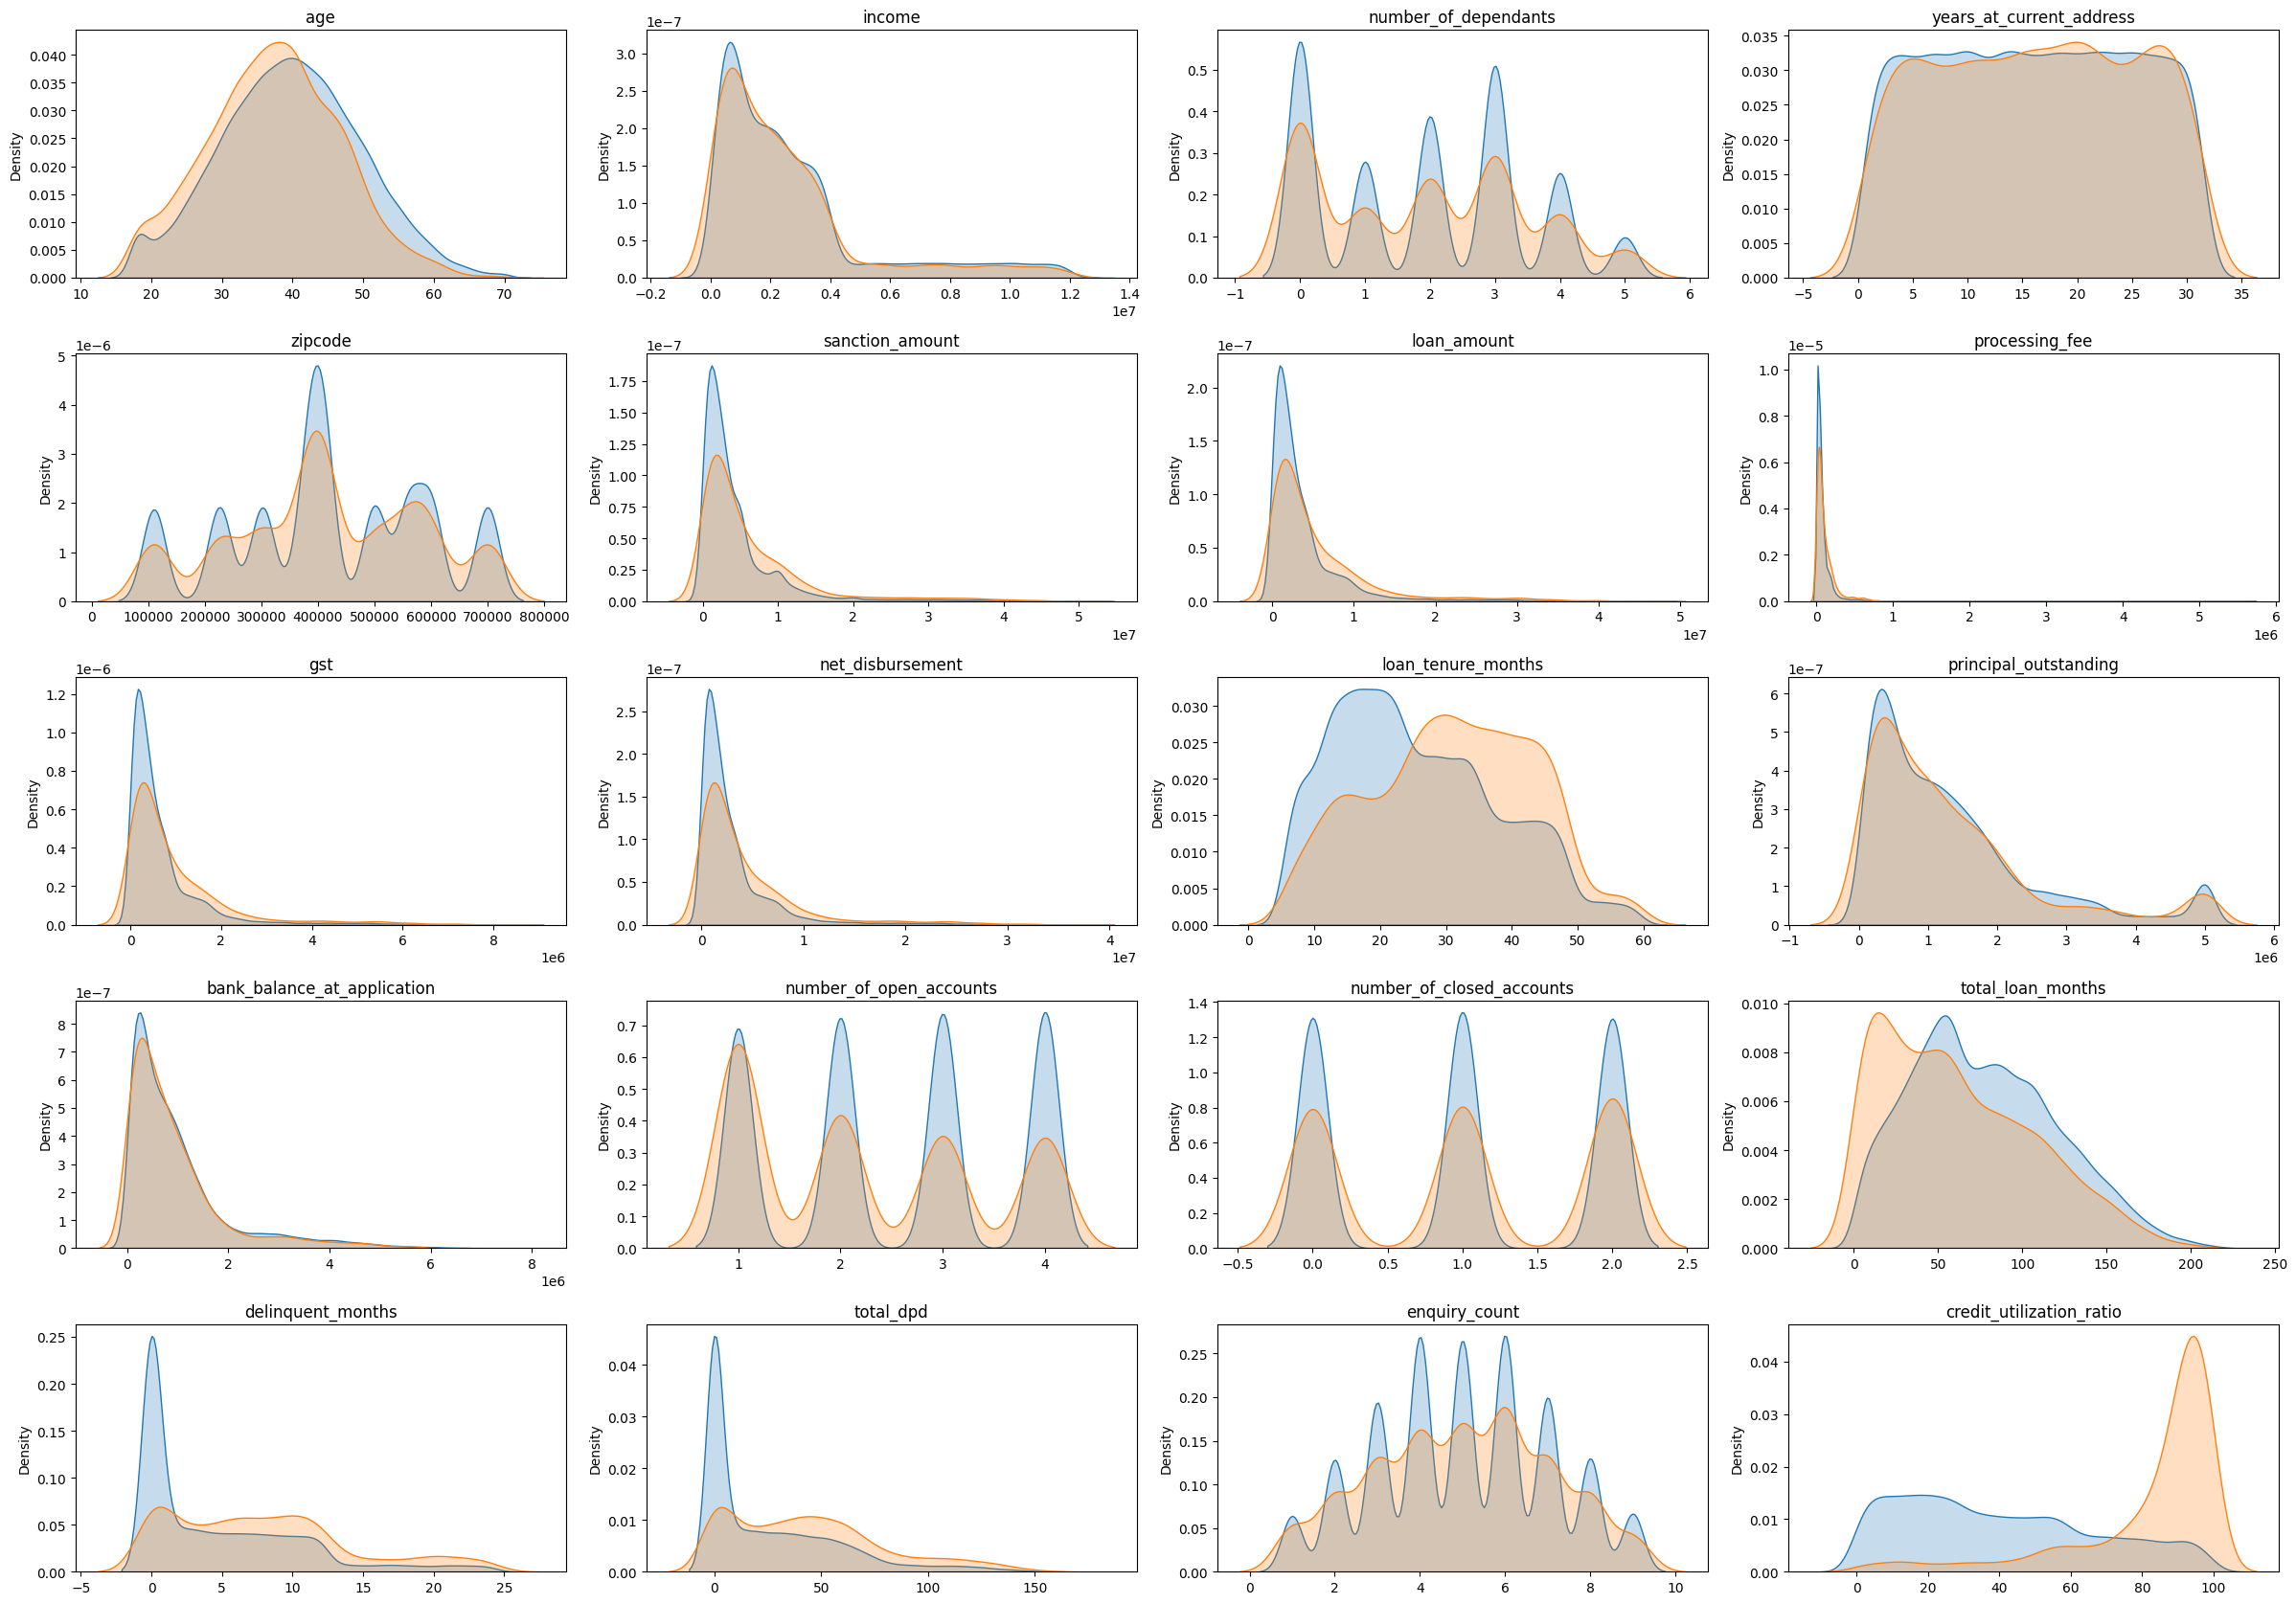

In [34]:
plt.figure(figsize=(24, 20))  # Width, height in inches

for i, col in enumerate(columns_continious):
    plt.subplot(6, 4, i+1)  # 1 row, 4 columns, ith subplot
    sns.kdeplot(df_train[col][df_train['default']==0], fill=True, label='default=0')
    sns.kdeplot(df_train[col][df_train['default']==1], fill=True, label='default=1')
    plt.title(col)
    plt.xlabel('')

plt.tight_layout()
plt.show()